# HW10-11 — классификация (S10) + сегментация (S11)

**Часть A:** `STL10`, эксперименты C1–C4.  
**Часть B:** `VOCSegmentation`, pretrained `DeepLabV3_ResNet50`, режимы V1/V2 (постобработка маски).

Запускайте из каталога `homeworks/HW10-11/` (или задайте `os.chdir` в первой ячейке). Данные пишутся в `./data/`, артефакты — в `./artifacts/`.

**Если Jupyter пишет «Kernel died» после блока с CNN:** сделайте **Kernel → Restart**, выполните все ячейки **с первой** (переменные `KMP_*` должны задаться до `import numpy`). При нехватке RAM уменьшите `BATCH_SIZE` во второй ячейке кода.

In [1]:
# 2.4.1 Импорты, seed, устройство
# Важно (Windows): переменные ниже — ДО import numpy/torch, иначе возможен «Kernel died» из-за OpenMP.
import os
import gc
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
os.environ.setdefault("OMP_NUM_THREADS", "4")
os.environ.setdefault("MKL_NUM_THREADS", "4")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "4")
import json
import csv
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

from torchvision import transforms
from torchvision.datasets import STL10, VOCSegmentation
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

_nt = min(4, max(1, (os.cpu_count() or 4)))
torch.set_num_threads(_nt)
torch.set_num_interop_threads(1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# Корень задания: ищем каталог с HW10-11.ipynb (cwd может быть repo root или homeworks/HW10-11)
_here = Path.cwd().resolve()
_cands = (_here, _here / "homeworks" / "HW10-11", _here.parent / "homeworks" / "HW10-11")
ROOT = _here
for c in _cands:
    if (c / "HW10-11.ipynb").exists():
        ROOT = c
        break
os.chdir(ROOT)
print("cwd:", ROOT)

device: cpu
cwd: C:\Users\Гошанский\PycharmProjects\mirea-aie\homeworks\HW10-11


In [2]:
# Пути и гиперпараметры (сопоставимые для C1–C4)
DATA_ROOT = ROOT / "data"
ARTIFACTS = ROOT / "artifacts"
FIGURES = ARTIFACTS / "figures"
for p in (DATA_ROOT, FIGURES):
    p.mkdir(parents=True, exist_ok=True)

# При OOM / «kernel died» уменьшите до 8–16
BATCH_SIZE = 16
NUM_WORKERS = 0  # Windows: 0 надёжнее для DataLoader
EPOCHS_CNN = 15
EPOCHS_RESNET = 12
LR_CNN = 1e-3
LR_HEAD = 1e-3
LR_FINETUNE = 1e-4

VAL_FRAC = 0.2  # от официального train STL10

In [3]:
# 2.4.2 Часть A: STL10, train/val/test
# Официально: train (5000), test (8000). Val выделяем из train.

base_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
])

aug_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(96, padding=8),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
])

# ImageNet stats для ResNet
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

resnet_train_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
resnet_eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

full_train = STL10(root=DATA_ROOT, split="train", download=True, transform=None)
n_train = len(full_train)
n_val = int(n_train * VAL_FRAC)
n_tr = n_train - n_val
gen = torch.Generator().manual_seed(SEED)
train_idx, val_idx = torch.randperm(n_train, generator=gen).split([n_tr, n_val])

# Отдельные датасеты с разными transform — через wrapper
class MapDataset(torch.utils.data.Dataset):
    def __init__(self, base_ds, indices, transform):
        self.base = base_ds
        self.indices = list(indices)
        self.transform = transform
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, i):
        img, y = self.base[self.indices[i]]
        if self.transform is not None:
            img = self.transform(img)
        return img, y

train_ds_c1 = MapDataset(full_train, train_idx, base_tf)
train_ds_c2 = MapDataset(full_train, train_idx, aug_tf)
val_ds_simple = MapDataset(full_train, val_idx, base_tf)

test_ds = STL10(root=DATA_ROOT, split="test", download=True, transform=base_tf)

# ResNet: отдельные train/val с ImageNet transforms
full_train_res = STL10(root=DATA_ROOT, split="train", download=True, transform=None)
train_ds_r = MapDataset(full_train_res, train_idx, resnet_train_tf)
val_ds_r = MapDataset(full_train_res, val_idx, resnet_eval_tf)
test_ds_r = STL10(root=DATA_ROOT, split="test", download=True, transform=resnet_eval_tf)

NUM_CLASSES = 10

load_kw = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

loader_c1_train = DataLoader(train_ds_c1, shuffle=True, **load_kw)
loader_c2_train = DataLoader(train_ds_c2, shuffle=True, **load_kw)
loader_val_simple = DataLoader(val_ds_simple, shuffle=False, **load_kw)
loader_test_simple = DataLoader(test_ds, shuffle=False, **load_kw)

loader_r_train = DataLoader(train_ds_r, shuffle=True, **load_kw)
loader_r_val = DataLoader(val_ds_r, shuffle=False, **load_kw)
loader_r_test = DataLoader(test_ds_r, shuffle=False, **load_kw)

print("train/val/test sizes:", n_tr, n_val, len(test_ds))

train/val/test sizes: 4000 1000 8000


batch x: torch.Size([16, 3, 96, 96]) y: torch.Size([16]) dtype: torch.float32


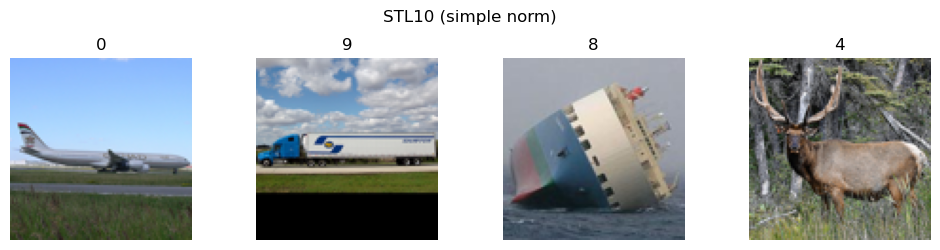

In [4]:
# Sanity-check часть A
xb, yb = next(iter(loader_c1_train))
print("batch x:", xb.shape, "y:", yb.shape, "dtype:", xb.dtype)

fig, ax = plt.subplots(1, 4, figsize=(10, 2.5))
for i in range(4):
    im = xb[i].permute(1, 2, 0).numpy()
    im = (im * 0.5 + 0.5).clip(0, 1)
    ax[i].imshow(im)
    ax[i].set_title(int(yb[i]))
    ax[i].axis("off")
plt.suptitle("STL10 (simple norm)")
plt.tight_layout()
plt.show()

In [5]:
# Простая CNN (одна архитектура для C1 и C2)
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.fc = nn.Linear(128 * 12 * 12, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.fc(x)


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += x.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        total_loss += loss.item() * x.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += x.size(0)
    return total_loss / total, correct / total


def train_classifier(model, train_loader, val_loader, epochs, lr, tag=""):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val = 0.0
    best_state = None
    for ep in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(va_acc)
        if va_acc > best_val:
            best_val = va_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        if ep == 1 or ep % max(1, epochs // 5) == 0 or ep == epochs:
            print(f"{tag} ep{ep}/{epochs}  train_loss={tr_loss:.4f} acc={tr_acc:.4f}  val_loss={va_loss:.4f} val_acc={va_acc:.4f}")
    if best_state is not None:
        model.load_state_dict(best_state)
    return history, best_val

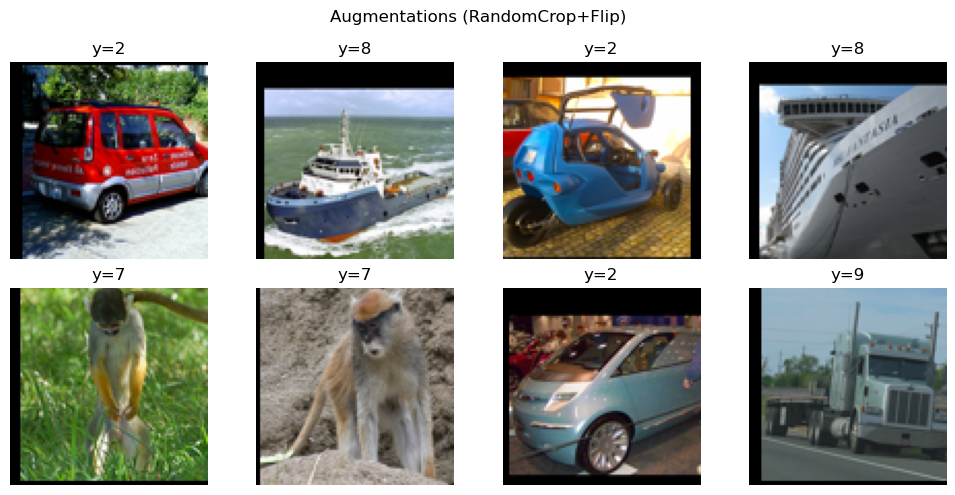

8048

In [6]:
# Аугментации: превью (сохраняем в artifacts)
rng = torch.Generator().manual_seed(SEED)
idx = torch.randint(0, len(train_ds_c2), (8,), generator=rng)
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
axes = axes.ravel()
raw = STL10(root=DATA_ROOT, split="train", download=False, transform=None)
for ax, k in zip(axes, idx):
    ii = int(train_idx[k].item())
    img, yi = raw[ii]
    timg = aug_tf(img)
    vis = timg.permute(1, 2, 0).numpy()
    vis = (vis * 0.5 + 0.5).clip(0, 1)
    ax.imshow(vis)
    ax.set_title(f"y={yi}")
    ax.axis("off")
plt.suptitle("Augmentations (RandomCrop+Flip)")
plt.tight_layout()
plt.savefig(FIGURES / "augmentations_preview.png", dpi=120)
plt.show()
plt.close(fig)
gc.collect()

In [7]:
# C1 и C2 — простая CNN
results_rows = []

torch.manual_seed(SEED)
model_c1 = SimpleCNN(NUM_CLASSES).to(device)
hist_c1, best_val_c1 = train_classifier(model_c1, loader_c1_train, loader_val_simple, EPOCHS_CNN, LR_CNN, tag="C1")
results_rows.append({
    "experiment_id": "C1", "task": "classification", "dataset": "STL10", "seed": SEED,
    "model_summary": "SimpleCNN no-aug", "optimizer": "Adam", "lr": LR_CNN,
    "epochs_trained": EPOCHS_CNN, "best_val_accuracy": best_val_c1, "test_accuracy": "",
    "precision": "", "recall": "", "mean_iou": "", "notes": "simple-cnn-base",
})

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

torch.manual_seed(SEED)
model_c2 = SimpleCNN(NUM_CLASSES).to(device)
hist_c2, best_val_c2 = train_classifier(model_c2, loader_c2_train, loader_val_simple, EPOCHS_CNN, LR_CNN, tag="C2")
results_rows.append({
    "experiment_id": "C2", "task": "classification", "dataset": "STL10", "seed": SEED,
    "model_summary": "SimpleCNN aug", "optimizer": "Adam", "lr": LR_CNN,
    "epochs_trained": EPOCHS_CNN, "best_val_accuracy": best_val_c2, "test_accuracy": "",
    "precision": "", "recall": "", "mean_iou": "", "notes": "simple-cnn-aug",
})

C1 ep1/15  train_loss=1.7675 acc=0.3570  val_loss=1.5237 val_acc=0.4470
C1 ep3/15  train_loss=1.0760 acc=0.6108  val_loss=1.3009 val_acc=0.5440
C1 ep6/15  train_loss=0.3439 acc=0.8825  val_loss=1.7114 val_acc=0.5600
C1 ep9/15  train_loss=0.0962 acc=0.9728  val_loss=2.7383 val_acc=0.5350
C1 ep12/15  train_loss=0.0319 acc=0.9912  val_loss=3.2067 val_acc=0.5500
C1 ep15/15  train_loss=0.0644 acc=0.9790  val_loss=3.5577 val_acc=0.5220
C2 ep1/15  train_loss=1.8839 acc=0.3030  val_loss=1.5848 val_acc=0.4200
C2 ep3/15  train_loss=1.3899 acc=0.4888  val_loss=1.3158 val_acc=0.5240
C2 ep6/15  train_loss=1.1742 acc=0.5790  val_loss=1.1933 val_acc=0.5650
C2 ep9/15  train_loss=1.0380 acc=0.6255  val_loss=1.1581 val_acc=0.5860
C2 ep12/15  train_loss=0.9317 acc=0.6705  val_loss=1.2250 val_acc=0.5970
C2 ep15/15  train_loss=0.8555 acc=0.6910  val_loss=1.1729 val_acc=0.6140


In [8]:
# C3, C4 — ResNet18 pretrained
def build_resnet(num_classes, freeze_backbone=True):
    w = ResNet18_Weights.IMAGENET1K_V1
    m = resnet18(weights=w)
    in_f = m.fc.in_features
    m.fc = nn.Linear(in_f, num_classes)
    if freeze_backbone:
        for p in m.parameters():
            p.requires_grad = False
        for p in m.fc.parameters():
            p.requires_grad = True
    return m


def unfreeze_layer4(model):
    for p in model.layer4.parameters():
        p.requires_grad = True
    for p in model.fc.parameters():
        p.requires_grad = True


torch.manual_seed(SEED)
model_c3 = build_resnet(NUM_CLASSES, freeze_backbone=True).to(device)
opt_c3 = torch.optim.Adam(filter(lambda p: p.requires_grad, model_c3.parameters()), lr=LR_HEAD)
hist_c3 = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_c3 = 0.0
best_state_c3 = None
cr = nn.CrossEntropyLoss()
for ep in range(1, EPOCHS_RESNET + 1):
    tr_loss, tr_acc = train_one_epoch(model_c3, loader_r_train, cr, opt_c3, device)
    va_loss, va_acc = evaluate(model_c3, loader_r_val, cr, device)
    hist_c3["train_loss"].append(tr_loss)
    hist_c3["val_loss"].append(va_loss)
    hist_c3["train_acc"].append(tr_acc)
    hist_c3["val_acc"].append(va_acc)
    if va_acc > best_val_c3:
        best_val_c3 = va_acc
        best_state_c3 = {k: v.cpu().clone() for k, v in model_c3.state_dict().items()}
    if ep == 1 or ep % 4 == 0 or ep == EPOCHS_RESNET:
        print(f"C3 ep{ep}/{EPOCHS_RESNET} tr_acc={tr_acc:.4f} val_acc={va_acc:.4f}")
if best_state_c3:
    model_c3.load_state_dict(best_state_c3)
results_rows.append({
    "experiment_id": "C3", "task": "classification", "dataset": "STL10", "seed": SEED,
    "model_summary": "ResNet18 head-only", "optimizer": "Adam", "lr": LR_HEAD,
    "epochs_trained": EPOCHS_RESNET, "best_val_accuracy": best_val_c3, "test_accuracy": "",
    "precision": "", "recall": "", "mean_iou": "", "notes": "resnet18-head-only",
})

torch.manual_seed(SEED)
model_c4 = build_resnet(NUM_CLASSES, freeze_backbone=True).to(device)
unfreeze_layer4(model_c4)
opt_c4 = torch.optim.Adam(
    [p for p in model_c4.parameters() if p.requires_grad], lr=LR_FINETUNE
)
hist_c4 = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_c4 = 0.0
best_state_c4 = None
for ep in range(1, EPOCHS_RESNET + 1):
    tr_loss, tr_acc = train_one_epoch(model_c4, loader_r_train, cr, opt_c4, device)
    va_loss, va_acc = evaluate(model_c4, loader_r_val, cr, device)
    hist_c4["train_loss"].append(tr_loss)
    hist_c4["val_loss"].append(va_loss)
    hist_c4["train_acc"].append(tr_acc)
    hist_c4["val_acc"].append(va_acc)
    if va_acc > best_val_c4:
        best_val_c4 = va_acc
        best_state_c4 = {k: v.cpu().clone() for k, v in model_c4.state_dict().items()}
    if ep == 1 or ep % 4 == 0 or ep == EPOCHS_RESNET:
        print(f"C4 ep{ep}/{EPOCHS_RESNET} tr_acc={tr_acc:.4f} val_acc={va_acc:.4f}")
if best_state_c4:
    model_c4.load_state_dict(best_state_c4)
results_rows.append({
    "experiment_id": "C4", "task": "classification", "dataset": "STL10", "seed": SEED,
    "model_summary": "ResNet18 layer4+fc finetune", "optimizer": "Adam", "lr": LR_FINETUNE,
    "epochs_trained": EPOCHS_RESNET, "best_val_accuracy": best_val_c4, "test_accuracy": "",
    "precision": "", "recall": "", "mean_iou": "", "notes": "resnet18-finetune",
})

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Гошанский/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:12<00:00, 3.69MB/s]


C3 ep1/12 tr_acc=0.7995 val_acc=0.9080
C3 ep4/12 tr_acc=0.9255 val_acc=0.9300
C3 ep8/12 tr_acc=0.9303 val_acc=0.9260
C3 ep12/12 tr_acc=0.9393 val_acc=0.9420
C4 ep1/12 tr_acc=0.8530 val_acc=0.9230
C4 ep4/12 tr_acc=0.9708 val_acc=0.9350
C4 ep8/12 tr_acc=0.9890 val_acc=0.9310
C4 ep12/12 tr_acc=0.9948 val_acc=0.9410


In [9]:
# Выбор лучшего по val; test один раз для лучшего
candidates = [
    ("C1", model_c1, best_val_c1, hist_c1, "SimpleCNN", "loader_test_simple", loader_test_simple),
    ("C2", model_c2, best_val_c2, hist_c2, "SimpleCNN", "loader_test_simple", loader_test_simple),
    ("C3", model_c3, best_val_c3, hist_c3, "ResNet18", "loader_r_test", loader_r_test),
    ("C4", model_c4, best_val_c4, hist_c4, "ResNet18", "loader_r_test", loader_r_test),
]
best_id, best_model, best_val, best_hist, best_arch, _, best_test_loader = max(candidates, key=lambda x: x[2])
print("Best by val:", best_id, "val_acc=", best_val)

@torch.no_grad()
def accuracy_loader(model, loader):
    model.eval()
    correct = 0
    total = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        pred = model(x).argmax(1)
        correct += (pred == y).sum().item()
        total += x.size(0)
    return correct / total

final_test_acc = accuracy_loader(best_model, best_test_loader)
print("Final test accuracy (best config only):", final_test_acc)

torch.save(best_model.state_dict(), ARTIFACTS / "best_classifier.pt")

best_cfg = {
    "seed": SEED,
    "dataset": "STL10",
    "best_experiment_id": best_id,
    "architecture": best_arch,
    "best_val_accuracy": float(best_val),
    "test_accuracy": float(final_test_acc),
    "imagenet_norm_for_resnet": best_id in ("C3", "C4"),
    "transforms_train": (
        "ResNet: Resize256+RandomCrop224+Flip+ImageNet norm"
        if best_id in ("C3", "C4")
        else ("SimpleCNN+aug: RandomCrop96+Flip+norm0.5" if best_id == "C2" else "SimpleCNN: ToTensor+norm0.5")
    ),
    "transforms_eval": (
        "ResNet: Resize256+CenterCrop224+ImageNet norm"
        if best_id in ("C3", "C4")
        else "ToTensor+norm0.5"
    ),
    "hyperparams": {
        "batch_size": BATCH_SIZE,
        "epochs_cnn": EPOCHS_CNN,
        "epochs_resnet": EPOCHS_RESNET,
        "lr_cnn": LR_CNN,
        "lr_head": LR_HEAD,
        "lr_finetune": LR_FINETUNE,
    },
}
with open(ARTIFACTS / "best_classifier_config.json", "w", encoding="utf-8") as f:
    json.dump(best_cfg, f, indent=2, ensure_ascii=False)

# Обновим строку лучшего эксперимента test_accuracy в runs — финальное число только у лучшего
for row in results_rows:
    if row["task"] == "classification":
        row["test_accuracy"] = float(final_test_acc) if row["experiment_id"] == best_id else ""


Best by val: C4 val_acc= 0.943
Final test accuracy (best config only): 0.9405


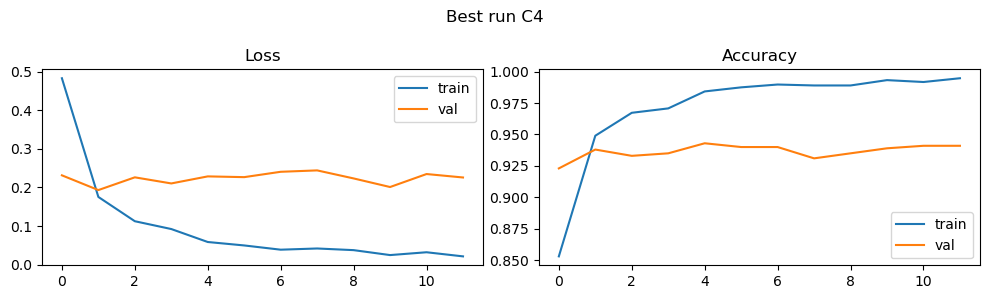

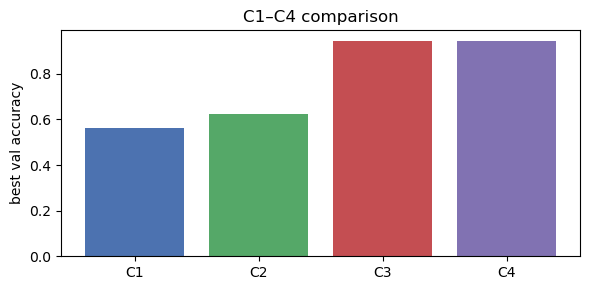

In [10]:
# Графики классификации
def plot_hist(hist, title, path):
    fig, ax = plt.subplots(1, 2, figsize=(10, 3))
    ax[0].plot(hist["train_loss"], label="train")
    ax[0].plot(hist["val_loss"], label="val")
    ax[0].set_title("Loss")
    ax[0].legend()
    ax[1].plot(hist["train_acc"], label="train")
    ax[1].plot(hist["val_acc"], label="val")
    ax[1].set_title("Accuracy")
    ax[1].legend()
    fig.suptitle(title)
    plt.tight_layout()
    plt.savefig(path, dpi=120)
    plt.show()

best_hist_map = {"C1": hist_c1, "C2": hist_c2, "C3": hist_c3, "C4": hist_c4}
plot_hist(best_hist_map[best_id], f"Best run {best_id}", FIGURES / "classification_curves_best.png")

labels = ["C1", "C2", "C3", "C4"]
vals = [best_val_c1, best_val_c2, best_val_c3, best_val_c4]
plt.figure(figsize=(6, 3))
plt.bar(labels, vals, color=["#4c72b0", "#55a868", "#c44e52", "#8172b2"])
plt.ylabel("best val accuracy")
plt.title("C1–C4 comparison")
plt.tight_layout()
plt.savefig(FIGURES / "classification_compare.png", dpi=120)
plt.show()

## Часть B: VOCSegmentation + DeepLabV3 (V1/V2)

- **Foreground:** все пиксели VOC, не равные классу 0 (фон).  
- **V1:** argmax по 21 классу → бинарная маска (fg = класс > 0).  
- **V2:** то же + удаление мелких компонент (`scipy.ndimage`); если `scipy` нет — морфологическое «закрытие» через max-pool/min-pool.

In [11]:
# Загрузка VOC val (для метрик — подмножество, чтобы уложиться в разумное время)
voc_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class VOCWrap(torch.utils.data.Dataset):
    def __init__(self, split, max_n=None):
        self.ds = VOCSegmentation(
            root=DATA_ROOT, year="2012", image_set=split, download=True,
            transform=voc_tf, target_transform=lambda m: m,
        )
        self.max_n = max_n if max_n is not None else len(self.ds)
        self.max_n = min(self.max_n, len(self.ds))

    def __len__(self):
        return self.max_n

    def __getitem__(self, i):
        img, mask_pil = self.ds[i]
        mask = torch.as_tensor(np.array(mask_pil), dtype=torch.long)
        mask[mask == 255] = 0  # границы как фон для бинарной постановки
        return img, mask

VOC_METRIC_N = 80  # увеличьте при необходимости
voc_val = VOCWrap("val", max_n=VOC_METRIC_N)
print("VOC metric subset:", len(voc_val))

weights_seg = DeepLabV3_ResNet50_Weights.DEFAULT
seg_model = deeplabv3_resnet50(weights=weights_seg).to(device)
seg_model.eval()

100%|██████████| 2.00G/2.00G [07:11<00:00, 4.63MB/s]


VOC metric subset: 80
Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to C:\Users\Гошанский/.cache\torch\hub\checkpoints\deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:34<00:00, 4.93MB/s] 


DeepLabV3(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Se

In [12]:
# Постобработка и метрики (бинарные)
try:
    from scipy import ndimage
    HAS_SCIPY = True
except Exception:
    HAS_SCIPY = False


def pred_to_binary(mask_logits):
    # mask_logits: [21,H,W]
    pred_cls = mask_logits.argmax(dim=0)
    return (pred_cls > 0).cpu().numpy().astype(np.uint8)


def postprocess_v2(binary_mask):
    m = binary_mask.astype(bool)
    if HAS_SCIPY:
        m = ndimage.binary_opening(m, structure=np.ones((3, 3)))
        labeled, n = ndimage.label(m)
        out = np.zeros_like(m, dtype=np.uint8)
        for lab in range(1, n + 1):
            comp = labeled == lab
            if comp.sum() >= 400:
                out[comp] = 1
        return out.astype(np.uint8)
    # fallback: torch morphological approx
    t = torch.from_numpy(m.astype(np.float32))[None, None]
    pad = F.pad(t, (1, 1, 1, 1), mode="reflect")
    dil = F.max_pool2d(pad, 3, stride=1)
    ero = -F.max_pool2d(-dil, 3, stride=1)
    return (ero[0, 0] > 0.5).numpy().astype(np.uint8)


def binary_iou(a, b):
    a = a.astype(bool)
    b = b.astype(bool)
    inter = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    if union == 0:
        return 1.0 if inter == 0 else 0.0
    return inter / union


def pixel_pr(a, b):
    # a = pred, b = gt
    tp = np.logical_and(a, b).sum()
    fp = np.logical_and(a, ~b).sum()
    fn = np.logical_and(~a, b).sum()
    prec = tp / (tp + fp + 1e-8)
    rec = tp / (tp + fn + 1e-8)
    return prec, rec

In [13]:
@torch.no_grad()
def run_segmentation_eval():
    ious_v1, ious_v2 = [], []
    p1, r1, p2, r2 = [], [], [], []
    for i in range(len(voc_val)):
        img, gt = voc_val[i]
        img_b = img.unsqueeze(0).to(device)
        out = seg_model(img_b)["out"][0]
        bin1 = pred_to_binary(out)
        gt_bin = (gt.numpy() > 0).astype(np.uint8)
        ious_v1.append(binary_iou(bin1, gt_bin))
        pr1 = pixel_pr(bin1.astype(bool), gt_bin.astype(bool))
        p1.append(pr1[0]); r1.append(pr1[1])

        bin2 = postprocess_v2(bin1)
        ious_v2.append(binary_iou(bin2, gt_bin))
        pr2 = pixel_pr(bin2.astype(bool), gt_bin.astype(bool))
        p2.append(pr2[0]); r2.append(pr2[1])
    return {
        "mean_iou_v1": float(np.mean(ious_v1)),
        "mean_iou_v2": float(np.mean(ious_v2)),
        "pixel_precision_v1": float(np.mean(p1)),
        "pixel_recall_v1": float(np.mean(r1)),
        "pixel_precision_v2": float(np.mean(p2)),
        "pixel_recall_v2": float(np.mean(r2)),
    }

metrics_plain = run_segmentation_eval()
print("Segmentation metrics:", metrics_plain)

Segmentation metrics: {'mean_iou_v1': 0.722978728689641, 'mean_iou_v2': 0.7199429794558279, 'pixel_precision_v1': 0.804638207114546, 'pixel_recall_v1': 0.8605381816363188, 'pixel_precision_v2': 0.7934998569897775, 'pixel_recall_v2': 0.8555416627642897}


In [14]:
# V1 / V2 строки в runs (постобработка: V1=argmax, V2=очистка)
results_rows.append({
    "experiment_id": "V1", "task": "segmentation", "dataset": "VOC2012", "seed": SEED,
    "model_summary": "DeepLabV3_ResNet50 COCO+VOC labels", "optimizer": "n/a", "lr": "",
    "epochs_trained": 0, "best_val_accuracy": "", "test_accuracy": "",
    "precision": metrics_plain["pixel_precision_v1"],
    "recall": metrics_plain["pixel_recall_v1"],
    "mean_iou": metrics_plain["mean_iou_v1"],
    "notes": "argmax binary fg",
})
results_rows.append({
    "experiment_id": "V2", "task": "segmentation", "dataset": "VOC2012", "seed": SEED,
    "model_summary": "DeepLabV3_ResNet50 COCO+VOC labels", "optimizer": "n/a", "lr": "",
    "epochs_trained": 0, "best_val_accuracy": "", "test_accuracy": "",
    "precision": metrics_plain["pixel_precision_v2"],
    "recall": metrics_plain["pixel_recall_v2"],
    "mean_iou": metrics_plain["mean_iou_v2"],
    "notes": "argmax + small-cc removal / morph cleanup",
})

FIELDNAMES = [
    "experiment_id", "task", "dataset", "seed", "model_summary", "optimizer", "lr",
    "epochs_trained", "best_val_accuracy", "test_accuracy", "precision", "recall", "mean_iou", "notes",
]
with open(ARTIFACTS / "runs.csv", "w", newline="", encoding="utf-8") as f:
    w = csv.DictWriter(f, fieldnames=FIELDNAMES)
    w.writeheader()
    for row in results_rows:
        w.writerow(row)
print("Wrote", ARTIFACTS / "runs.csv")

Wrote C:\Users\Гошанский\PycharmProjects\mirea-aie\homeworks\HW10-11\artifacts\runs.csv


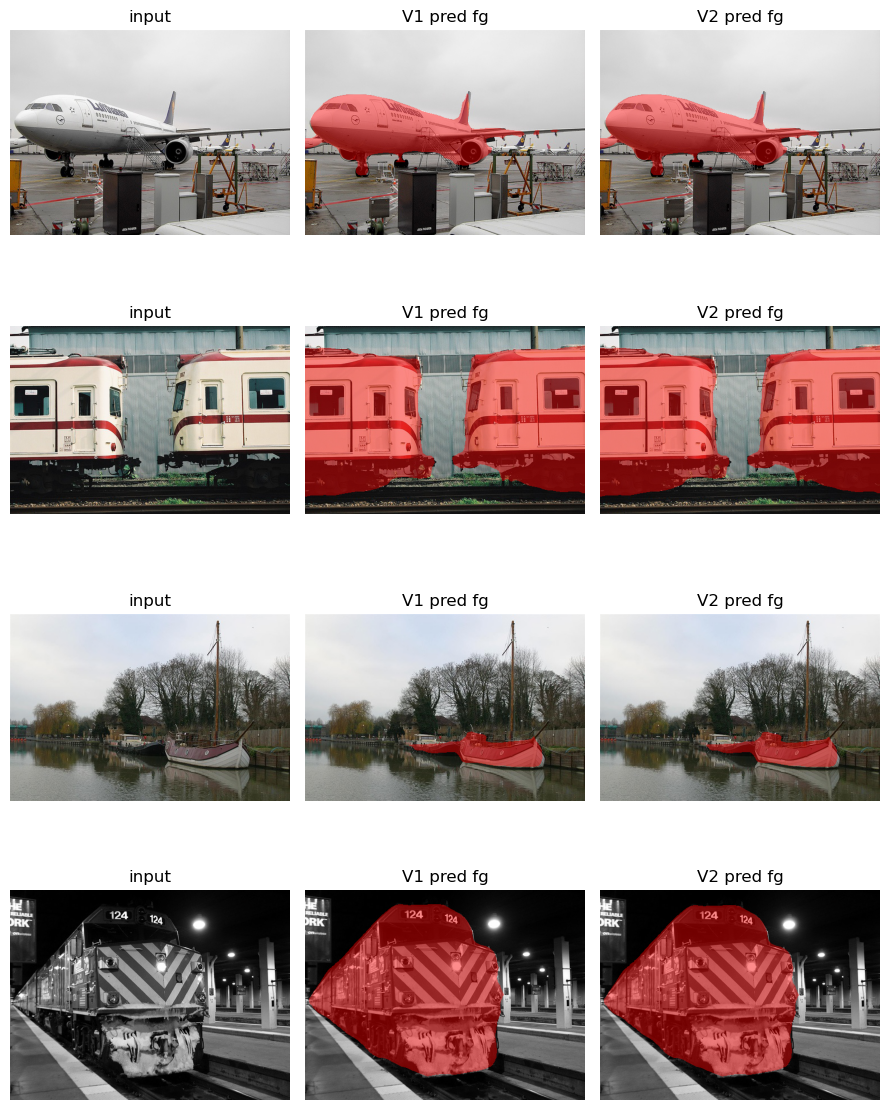

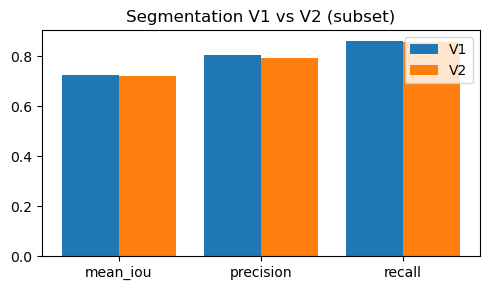

In [15]:
# Визуализация сегментации
def overlay(img_tensor, mask_bin, alpha=0.45):
    # img_tensor [3,H,W] normalized ImageNet
    x = img_tensor.detach().cpu()
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    im = (x * std + mean).permute(1, 2, 0).numpy().clip(0, 1)
    h, w = im.shape[:2]
    color = np.zeros((h, w, 4))
    color[..., 0] = 1.0
    color[..., 3] = mask_bin.astype(np.float32) * alpha
    return im, color


@torch.no_grad()
def show_seg_examples(n=4):
    fig, axes = plt.subplots(n, 3, figsize=(9, 3 * n))
    if n == 1:
        axes = np.expand_dims(axes, 0)
    for row in range(n):
        img, gt = voc_val[row]
        out = seg_model(img.unsqueeze(0).to(device))["out"][0]
        bin1 = pred_to_binary(out)
        bin2 = postprocess_v2(bin1)
        gt_bin = (gt.numpy() > 0).astype(np.uint8)
        im0, ov1 = overlay(img, bin1)
        im1, ov2 = overlay(img, bin2)
        axes[row, 0].imshow(im0)
        axes[row, 0].set_title("input")
        axes[row, 0].axis("off")
        axes[row, 1].imshow(im0)
        axes[row, 1].imshow(ov1)
        axes[row, 1].set_title("V1 pred fg")
        axes[row, 1].axis("off")
        axes[row, 2].imshow(im1)
        axes[row, 2].imshow(ov2)
        axes[row, 2].set_title("V2 pred fg")
        axes[row, 2].axis("off")
    plt.tight_layout()
    plt.savefig(FIGURES / "segmentation_examples.png", dpi=130)
    plt.show()

show_seg_examples(4)

# График метрик V1 vs V2
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
names = ["mean_iou", "precision", "recall"]
v1y = [metrics_plain["mean_iou_v1"], metrics_plain["pixel_precision_v1"], metrics_plain["pixel_recall_v1"]]
v2y = [metrics_plain["mean_iou_v2"], metrics_plain["pixel_precision_v2"], metrics_plain["pixel_recall_v2"]]
x = np.arange(len(names))
ax.bar(x - 0.2, v1y, 0.4, label="V1")
ax.bar(x + 0.2, v2y, 0.4, label="V2")
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.legend()
ax.set_title("Segmentation V1 vs V2 (subset)")
plt.tight_layout()
plt.savefig(FIGURES / "segmentation_metrics.png", dpi=120)
plt.show()

In [16]:
print("Done. Artifacts in:", ARTIFACTS)

Done. Artifacts in: C:\Users\Гошанский\PycharmProjects\mirea-aie\homeworks\HW10-11\artifacts
